#**Offline Training(Representation Learning)**

##Step 1:Data ingestion & normalization

###Step 1.1 – Mount Drive and Install Requirements

In [ ]:
!pip install rasterio tifffile matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 48.6 MB/s eta 0:00:00


In [ ]:
#Mounting of Drive for dataset access
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


###Step 1.2 – Read TIFF (4 bands)

In [ ]:
#Loading the TIFF images
import os
from glob import glob
import rasterio
tiff_dir = "/content/drive/MyDrive/NCIIPC Startup Challenge/Datasets/development-set"
tiff_files = sorted(glob(os.path.join(tiff_dir, "*.tif")))

print("TIFF count:", len(tiff_files))
print("Example:", tiff_files[0])

def load_tiff(path):
    with rasterio.open(path) as src:
        img = src.read()  # shape: (bands, H, W)
        img = np.transpose(img, (1,2,0))  # shape: (H, W, bands)
    return img.astype(np.float32)


TIFF count: 150
Example: /content/drive/MyDrive/NCIIPC Startup Challenge/Datasets/development-set/GC01PS03D0001.tif


###Step 1.3 – Compute Dataset Statistics (Normalization)

In [ ]:
#Normalization of TIFF images
import numpy as np

band_sums = np.zeros(4, dtype=np.float64)
band_sq_sums = np.zeros(4, dtype=np.float64)
pixel_count = 0

for path in tiff_files:
    img = load_tiff(path)   # shape (H,W,4)
    img = img / 10000.0     # scale to [0,1]
    h, w, c = img.shape
    band_sums += img.reshape(-1,4).sum(axis=0)
    band_sq_sums += (img.reshape(-1,4)**2).sum(axis=0)
    pixel_count += h*w

means = band_sums / pixel_count
stds = np.sqrt(band_sq_sums/pixel_count - means**2)

print("TIFF means:", means)
print("TIFF stds:", stds)


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


TIFF means: [0.10424103 0.09752644 0.06988158 0.24941396]
TIFF stds: [0.06071128 0.0460257  0.03620632 0.09986798]


In [ ]:
#Saving to JSON File for later use for further preprocessing
import json

stats = {
    "bands": ["Blue", "Green", "Red", "NIR"],
    "scale_divisor": 10000.0,
    "means": means.tolist(),
    "stds": stds.tolist()
}

with open("/content/drive/MyDrive/NCIIPC Startup Challenge/preprocess.json", "w") as f:
    json.dump(stats, f, indent=4)


###Step 1.4 – Patch Sampling (for SSL training)

In [ ]:
#Patching
import random

PATCH_SIZE = 128

def sample_patch(file_list, patch_size=PATCH_SIZE):
    path = random.choice(file_list)
    img = load_tiff(path) / 10000.0
    h, w, c = img.shape

    y = random.randint(0, h - patch_size)
    x = random.randint(0, w - patch_size)

    patch = img[y:y+patch_size, x:x+patch_size, :]

    # Normalize using dataset stats
    patch = (patch - means) / stds
    return patch  # shape (128,128,4)


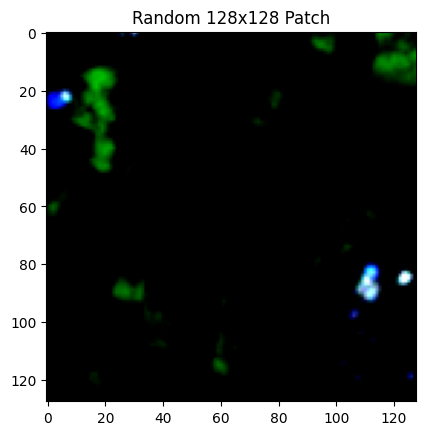

In [ ]:
#Checking the patches sample
import matplotlib.pyplot as plt

patch = sample_patch(tiff_files)
plt.imshow(patch[:,:,:3])  # RGB only (ignore NIR for visualization)
plt.title("Random 128x128 Patch")
plt.show()


###Step 1.5 – Build a PyTorch Dataset (for SSL training later)

In [ ]:
#Building a Pytorch Dataset
import torch
from torch.utils.data import Dataset

class SatellitePatchDataset(Dataset):
    def __init__(self, file_list, patch_size=128, n_samples=100000):
        self.file_list = file_list
        self.patch_size = patch_size
        self.n_samples = n_samples  # total samples per epoch

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        patch = sample_patch(self.file_list, self.patch_size)
        patch = np.transpose(patch, (2,0,1))  # (C,H,W)
        return torch.tensor(patch, dtype=torch.float32)

# Example: create a dataset
dataset = SatellitePatchDataset(tiff_files, patch_size=128, n_samples=10000)
print(len(dataset))
patch_tensor = dataset[0]
print(patch_tensor.shape)  # should be (4,128,128)


10000


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


torch.Size([4, 128, 128])


##Step2:Choosing one SSL Baseline



> We choose MocoV2+Resnet-50



##Step 3:Augmentations

> Geometric+Photometric augmentation per band



In [ ]:
import torch
import torch.nn.functional as F
import random

# --- helpers ---
import torch, numpy as np

def ensure_chw4(x):
    # Accepts torch.Tensor or np.ndarray; returns torch.FloatTensor (4,H,W)
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x)
    x = x.float()
    if x.ndim == 3:
        # already CHW?
        if x.shape[0] == 4:
            return x.contiguous()
        # was HWC?
        if x.shape[-1] == 4:
            return x.permute(2, 0, 1).contiguous()
    raise ValueError(f"Augmentation produced wrong shape {tuple(x.shape)}; need (4,H,W) or (H,W,4).")


def rand_crop_and_resize(x, out_hw=(128,128), scale_range=(0.5, 1.0)):
    # x: (C,H,W), values normalized
    C, H, W = x.shape
    s = random.uniform(*scale_range)
    h = max(8, int(H * s))
    w = max(8, int(W * s))
    if h < H or w < W:
        top = random.randint(0, H - h)
        left = random.randint(0, W - w)
        x = x[:, top:top+h, left:left+w]
    x = x.unsqueeze(0)  # (1,C,h,w)
    x = F.interpolate(x, size=out_hw, mode='bilinear', align_corners=False)
    return x.squeeze(0)

def rand_flip_rotate(x):
    # flips
    if random.random() < 0.5:
        x = torch.flip(x, dims=[2])  # horizontal
    if random.random() < 0.5:
        x = torch.flip(x, dims=[1])  # vertical
    # 90° rotations
    k = random.choice([0,1,2,3])
    if k > 0:
        x = torch.rot90(x, k, dims=[1,2])
    return x

def per_band_brightness_contrast(x, b_range=0.2, c_range=0.2):
    # x normalized; apply small affine per band
    C, H, W = x.shape
    # inverse-normalize to ~[0,1] if you prefer, then re-normalize afterwards (optional).
    for c in range(C):
        b = random.uniform(-b_range, b_range)
        g = 1.0 + random.uniform(-c_range, c_range)
        x[c] = torch.clamp(g * x[c] + b, min=x[c].min().item() - 1.0, max=x[c].max().item() + 1.0)
    return x

def gaussian_blur(x, p=0.3, k=3):
    if random.random() >= p:
        return x
    # simple box/gaussian-ish blur via average pooling as a fast proxy
    pad = k // 2
    x = F.avg_pool2d(x.unsqueeze(0), kernel_size=k, stride=1, padding=pad).squeeze(0)
    return x

def gaussian_noise(x, sigma_range=(0.0, 0.02)):
    sigma = random.uniform(*sigma_range)
    if sigma <= 0:
        return x
    noise = torch.randn_like(x) * sigma
    return x + noise

def channel_dropout(x, p=0.12, which='random'):
    if random.random() >= p:
        return x
    C, _, _ = x.shape
    if which == 'nir':
        drop_idx = 3 if C >= 4 else random.randrange(C)
    else:
        drop_idx = random.randrange(C)
    x[drop_idx] = 0.0
    return x

def random_erasing(x, p=0.25, erase_scale=(0.02, 0.10)):
    if random.random() >= p:
        return x
    C, H, W = x.shape
    area = H * W
    target = random.uniform(*erase_scale) * area
    h = int(max(2, (target ** 0.5)))
    w = int(max(2, target / max(h, 1)))
    if h >= H or w >= W:
        return x
    top = random.randint(0, H - h)
    left = random.randint(0, W - w)
    x[:, top:top+h, left:left+w] = 0.0
    return x

def clamp_like(x, lo=-10.0, hi=10.0):
    # keep values in a safe numeric range post-augment
    return torch.clamp(x, lo, hi)

def make_view(x, out_hw=(128,128)):
    # x: (C,H,W) normalized
    y = rand_crop_and_resize(x, out_hw, (0.5, 1.0))
    y = rand_flip_rotate(y)
    y = per_band_brightness_contrast(y, 0.20, 0.20)
    y = gaussian_blur(y, p=0.30, k=3)
    y = gaussian_noise(y, (0.0, 0.02))
    y = channel_dropout(y, p=0.12, which='nir')
    y = random_erasing(y, p=0.25, erase_scale=(0.02, 0.10))
    y = clamp_like(y)
    return y

In [ ]:
def __getitem__(self, idx):
    import random, rasterio, numpy as np, torch

    # --- 1) Pick a random TIFF ---
    path = random.choice(self.files)
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)   # (C,H,W)
    assert arr.shape[0] == 4, f"Expected 4 bands, got {arr.shape}"

    # --- 2) Random crop ---
    C,H,W = arr.shape
    y = random.randint(0, H - self.patch_size)
    x = random.randint(0, W - self.patch_size)
    patch = arr[:, y:y+self.patch_size, x:x+self.patch_size] / self.scale  # (4,P,P)

    # --- 3) To torch tensor ---
    patch = torch.from_numpy(patch)  # (4,P,P)

    # --- 4) Normalize ---
    if self.means is not None and self.stds is not None:
        patch = (patch - self.means) / self.stds

    # --- 5) Augment twice ---
    v1 = make_view(patch)            # (4,P,P)
    v2 = make_view(patch.clone())    # (4,P,P)

    # --- 6) Safety check ---
    assert v1.shape[0] == 4, f"v1 wrong shape {tuple(v1.shape)}"
    assert v2.shape[0] == 4, f"v2 wrong shape {tuple(v2.shape)}"

    return v1, v2


In [ ]:
from torch.utils.data import DataLoader
import torch

def collate_two_views(batch):
    v1 = torch.stack([b[0] for b in batch], dim=0)  # (B,4,P,P)
    v2 = torch.stack([b[1] for b in batch], dim=0)  # (B,4,P,P)
    return v1, v2

loader = DataLoader(dataset,
                    batch_size=32,      # your B
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True,
                    collate_fn=collate_two_views)


view1_batch, view2_batch = next(iter(loader))
print(view1_batch.shape, view2_batch.shape)   # both (32,4,128,128)
print(view1_batch, view2_batch)


torch.Size([32, 128, 128]) torch.Size([32, 128, 128])
tensor([[[-8.9672e-01, -9.3131e-01, -9.6919e-01,  ..., -7.6989e-01,
          -7.8471e-01, -7.8966e-01],
         [-9.1484e-01, -9.0001e-01, -8.8025e-01,  ..., -7.6001e-01,
          -7.5177e-01, -7.7483e-01],
         [-8.9178e-01, -9.0825e-01, -9.0331e-01,  ..., -8.0942e-01,
          -7.9460e-01, -7.9624e-01],
         ...,
         [-7.0895e-01, -7.1553e-01, -7.2542e-01,  ..., -8.5554e-01,
          -8.5719e-01, -8.4236e-01],
         [-6.9412e-01, -6.8918e-01, -7.0071e-01,  ..., -8.6378e-01,
          -8.4566e-01, -8.4731e-01],
         [-6.8424e-01, -6.7765e-01, -6.7600e-01,  ..., -8.4236e-01,
          -8.0448e-01, -8.3248e-01]],

        [[-7.5507e-01, -7.3530e-01, -7.2048e-01,  ..., -5.6565e-01,
          -4.6846e-01, -4.3552e-01],
         [-7.5836e-01, -7.5177e-01, -7.5507e-01,  ..., -5.5411e-01,
          -4.7011e-01, -4.6682e-01],
         [-7.8471e-01, -7.9130e-01, -7.8142e-01,  ..., -6.1835e-01,
          -5.8376e-01,

In [ ]:
# DATASET: returns CHW tensors
class TwoViewTiffDataset(Dataset):
    def __init__(self, tiff_files, patch_size=128, n_samples=100000, means=None, stds=None, scale=10000.0):
        self.files = list(tiff_files)
        self.patch_size = patch_size
        self.n_samples = n_samples
        self.means = torch.tensor(means, dtype=torch.float32).view(4,1,1) if means is not None else None
        self.stds  = torch.tensor(stds,  dtype=torch.float32).view(4,1,1) if stds  is not None else None
        self.scale = scale

    def __len__(self): return self.n_samples

    def __getitem__(self, idx):
        import random, rasterio, numpy as np, torch
        path = random.choice(self.files)
        with rasterio.open(path) as src:
            arr = src.read().astype(np.float32)  # (C,H,W)
        assert arr.shape[0] == 4, f"Expected 4 bands, got {arr.shape}"

        # random crop
        C,H,W = arr.shape
        y = random.randint(0, H - self.patch_size)
        x = random.randint(0, W - self.patch_size)
        patch = arr[:, y:y+self.patch_size, x:x+self.patch_size] / self.scale  # (4,P,P)

        patch = torch.from_numpy(patch)  # (4,P,P)
        if self.means is not None and self.stds is not None:
            patch = (patch - self.means) / self.stds  # keep CHW

        # two independent augmented views (must return CHW)
        v1 = make_view(patch)            # (4,P,P)
        v2 = make_view(patch.clone())    # (4,P,P)
        assert v1.shape[0] == 4 and v2.shape[0] == 4, f"Augmentations must return CHW; got {v1.shape}, {v2.shape}"
        return v1, v2

# COLLATE: stack on batch dim (dim=0)
def collate_two_views(batch):
    v1 = torch.stack([b[0] for b in batch], dim=0)  # (B,4,P,P)
    v2 = torch.stack([b[1] for b in batch], dim=0)  # (B,4,P,P)
    return v1, v2

loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2,
                    pin_memory=True, collate_fn=collate_two_views)


In [ ]:
dataset = TwoViewTiffDataset(tiff_files, patch_size=128, n_samples=1000, means=means, stds=stds)
v1, v2 = dataset[0]
print("item shapes:", v1.shape, v2.shape)

item shapes: torch.Size([4, 128, 128]) torch.Size([4, 128, 128])


In [ ]:
loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_two_views)
v1b, v2b = next(iter(loader))
print("batch shapes:", v1b.shape, v2b.shape)


batch shapes: torch.Size([32, 4, 128, 128]) torch.Size([32, 4, 128, 128])


##Step 4: Losses & Heads

> MoCo-v2 with ResNet-50, 4-band



###Step 4.1-One time setup  before training

In [ ]:
!pip -q install rasterio tifffile torchvision==0.18.1 torch==2.8.0

ERROR: Cannot install torch==2.8.0 and torchvision==0.18.1 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50
# --- 1) Backbone (ResNet-50 modified for 4 channels) ---
def resnet50_4ch():
    m = resnet50(weights=None)
    # change first conv layer: 3 -> 4 channels
    w = m.conv1.weight  # original weights (64,3,7,7)
    m.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
    # initialize: copy RGB weights to new conv, init 4th (NIR) as mean of RGB
    with torch.no_grad():
        m.conv1.weight[:, :3] = w
        m.conv1.weight[:, 3:4] = w.mean(dim=1, keepdim=True)
    m.fc = nn.Identity()   # remove classification head
    return m  # output: 2048-D feature vector after global avg pooling



In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.3.1+cu121 torchvision==0.18.1+cu121 -f https://download.pytorch.org/whl/torch_stable.html

Found existing installation: torch 2.3.1
Uninstalling torch-2.3.1:
  Successfully uninstalled torch-2.3.1
Found existing installation: torchvision 0.18.1
Uninstalling torchvision-0.18.1:
  Successfully uninstalled torchvision-0.18.1
Found existing installation: torchaudio 2.8.0+cu126
Uninstalling torchaudio-2.8.0+cu126:
  Successfully uninstalled torchaudio-2.8.0+cu126
Looking in links: https://download.pytorch.org/whl/torch_stable.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 801.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 49.8 MB/s eta 0:00:00


In [ ]:
# --- 2) Projection Head (MLP: 2048 -> 2048 -> 128) ---
class ProjectionMLP(nn.Module):
    def __init__(self, in_dim=2048, hid_dim=2048, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid_dim, bias=False),
            nn.BatchNorm1d(hid_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hid_dim, out_dim, bias=True)
        )
    def forward(self, x):
        z = self.net(x)
        return F.normalize(z, dim=1)   # L2 normalize (cosine similarity)

In [ ]:
# --- 3) Encoder Wrapper (Backbone + Projection) ---
class EncoderWithProj(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.backbone = resnet50_4ch()
        self.proj = ProjectionMLP(2048, 2048, out_dim)

    def forward(self, x):
        feats = self.backbone(x)    # (B,2048)
        z = self.proj(feats)        # (B,128), normalized
        return z, feats


In [ ]:
# --- 4) MoCo-v2 Container: Two encoders + Negative Queue ---
class MoCoV2(nn.Module):
    def __init__(self, out_dim=128, K=65536, m=0.999, T=0.2, device='cuda'):
        super().__init__()
        # query encoder (with grads)
        self.enc_q = EncoderWithProj(out_dim)
        # key encoder (momentum, no grads)
        self.enc_k = EncoderWithProj(out_dim)
        self.register_buffer("queue", torch.randn(out_dim, K))
        self.queue = F.normalize(self.queue, dim=0)
        self.queue.requires_grad_(False)  # <- add this line


        # initialize enc_k params = enc_q params
        for p_q, p_k in zip(self.enc_q.parameters(), self.enc_k.parameters()):
            p_k.data.copy_(p_q.data)
            p_k.requires_grad = False

        # key hyperparameters
        self.K = K   # queue size
        self.m = m   # momentum coefficient
        self.T = T   # temperature

        # negative queue (buffer)
        self.register_buffer("queue", torch.randn(out_dim, K))
        self.queue = F.normalize(self.queue, dim=0)  # normalize along dim 0
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

        self.device = device

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        """Update key encoder weights: enc_k = m*enc_k + (1-m)*enc_q"""
        for p_q, p_k in zip(self.enc_q.parameters(), self.enc_k.parameters()):
            p_k.data = p_k.data * self.m + p_q.data * (1. - self.m)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        """Add new keys to the queue, remove oldest ones"""
        bs = keys.shape[0]
        ptr = int(self.queue_ptr)
        assert self.K % bs == 0, "Queue size must be divisible by batch size"
        # Create a copy of the queue before updating
        queue_copy = self.queue.clone()
        queue_copy[:, ptr:ptr+bs] = keys.T
        self.queue.copy_(queue_copy) # Use copy_ to update the original queue tensor
        ptr = (ptr + bs) % self.K
        self.queue_ptr[0] = ptr

    def contrastive_step(self, im_q, im_k):
        """
        im_q, im_k: (B, 4, 128, 128)
        Returns: loss, logits, labels
        """
        # 1) Query path (trainable)
        q, _ = self.enc_q(im_q)                         # (B, 128), already L2-normalized

        # 2) Momentum update + Key path (no grad)
        with torch.no_grad():
            self._momentum_update_key_encoder()
            k, _ = self.enc_k(im_k)                     # (B, 128), L2-normalized

        # 3) Build logits: pos + neg
        l_pos = (q * k).sum(dim=1, keepdim=True)  # (B,1)
    # CRITICAL: use a detached COPY of the queue for negatives
        l_neg = q @ self.queue.clone().detach()   # (B,K)

        logits = torch.cat([l_pos, l_neg], dim=1) / self.T
        labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)
    # 4) InfoNCE loss
        loss = F.cross_entropy(logits, labels)

    # 5) DO NOT update the queue here. Return k; enqueue after backward.
        return loss, logits, labels, k.detach()

##Step 5:Training Loop

###Step 5.1-Training helpers

In [ ]:
#Training of helpers
import torch
from torch.cuda.amp import autocast, GradScaler

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Instantiate the MoCo-v2 model
model = MoCoV2(device=device)
model.to(device)

# Optimizer / LR schedule / AMP scaler
optimizer = torch.optim.AdamW(model.enc_q.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)  # epochs
scaler = GradScaler(enabled=torch.cuda.is_available())

/tmp/ipython-input-3867117397.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


###Step 5.2-One epoch Training

In [ ]:
#One epoch of training
def train_one_epoch(model, loader, optimizer, scaler, epoch, log_interval=50):
    model.train()
    running = 0.0

    for it, (v1, v2) in enumerate(loader, start=1):
        v1 = v1.to(device, non_blocking=True)
        v2 = v2.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            # Your MoCo step: computes q/k, logits, InfoNCE, updates queue
            loss, logits, labels, k = model.contrastive_step(v1, v2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()

        if it % log_interval == 0:
            print(f"Epoch {epoch:03d} | iter {it:05d} | avg_loss {running/it:.4f}")

    return running / it  # average epoch loss

###Step 5.3-Training loop across epochs + checkpointing

In [ ]:
import os

EPOCHS = 10
CKPT_DIR = "/content/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(model, optimizer, scheduler, scaler, epoch, path):
    torch.save({
        "epoch": epoch,
        "enc_q_backbone": model.enc_q.backbone.state_dict(),
        "enc_q_proj": model.enc_q.proj.state_dict(),
        "enc_k_backbone": model.enc_k.backbone.state_dict(),
        "enc_k_proj": model.enc_k.proj.state_dict(),
        "queue": model.queue,
        "queue_ptr": model.queue_ptr,
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
    }, path)

for ep in range(1, EPOCHS+1):
    avg_loss = train_one_epoch(model, loader, optimizer, scaler, ep)
    scheduler.step()

    # Light logging each epoch
    print(f"[Epoch {ep:03d}] loss={avg_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}")

    # Save a checkpoint every 10 epochs (and the first one)
    if ep == 1 or ep % 10 == 0:
        ckpt_path = os.path.join(CKPT_DIR, f"moco_ep{ep:03d}.pt")
        save_checkpoint(model, optimizer, scheduler, scaler, ep, ckpt_path)
        print(f"Saved checkpoint: {ckpt_path}")

# Save the final query encoder (for downstream indexing/retrieval)
torch.save({
    "backbone": model.enc_q.backbone.state_dict(),
    "projector": model.enc_q.proj.state_dict(),
}, "/content/encoder_moco_resnet50_4ch.pt")
print("Saved final encoder: /content/encoder_moco_resnet50_4ch.pt")


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/tmp/ipython-input-363872780.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


KeyboardInterrupt: 

Need to resume training → use /content/checkpoints/moco_epXXX.pt.

Need to embed/query → use /content/encoder_moco_resnet50_4ch.pt.

###Step 5.4-Saving of the trained checkpoints

In [ ]:
import os
drive_ckpt_dir = "/content/drive/MyDrive/NCIIPC Startup Challenge/checkpoints"
os.makedirs(drive_ckpt_dir, exist_ok=True)

import shutil

# Copy the whole folder
shutil.copytree("/content/checkpoints", drive_ckpt_dir, dirs_exist_ok=True)

print("✅ Copied checkpoints to:", drive_ckpt_dir)



FileNotFoundError: [Errno 2] No such file or directory: '/content/checkpoints'

In [ ]:
import shutil

src = "/content/encoder_moco_resnet50_4ch.pt"   # current location in Colab
dst = "/content/drive/MyDrive/NCIIPC Startup Challenge/checkpoints"  # save path in Drive

shutil.copy2(src, dst)
print("✅ Encoder snapshot saved to Drive:", dst)


✅ Encoder snapshot saved to Drive: /content/drive/MyDrive/NCIIPC Startup Challenge/checkpoints


###Step 5.5-Resuming of training of encoder

---



In [ ]:
# 1) Paths
CKPT_DIR  = "/content/drive/MyDrive/NCIIPC Startup Challenge/checkpoints"
CKPT_PATH = f"{CKPT_DIR}/moco_ep225.pt"   # <-- resume from last finished epoch 20

# 2) Rebuild model/optimizer/scheduler/scaler EXACTLY as before
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- your MoCoV2 / EncoderWithProj classes must already be defined above ---

model = MoCoV2(out_dim=128, K=65536, m=0.999, T=0.2, device=device).to(device)

optimizer = torch.optim.AdamW(model.enc_q.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)
from torch.cuda.amp import GradScaler
# Initialize GradScaler with enabled=True when loading from a checkpoint
scaler = GradScaler(enabled=True)

# 3) Load checkpoint and restore training state
ckpt = torch.load(CKPT_PATH, map_location="cpu")

# encoders
model.enc_q.backbone.load_state_dict(ckpt["enc_q_backbone"])
model.enc_q.proj.load_state_dict(ckpt["enc_q_proj"])
model.enc_k.backbone.load_state_dict(ckpt["enc_k_backbone"])
model.enc_k.proj.load_state_dict(ckpt["enc_k_proj"])

# queue buffers
model.queue.copy_(ckpt["queue"])
model.queue_ptr.copy_(ckpt["queue_ptr"])

# optimizer / scheduler / scaler
optimizer.load_state_dict(ckpt["optimizer"])
if ckpt.get("scheduler") is not None:
    scheduler.load_state_dict(ckpt["scheduler"])
# Only load scaler state if it exists in the checkpoint and is not empty
if ckpt.get("scaler") is not None and ckpt["scaler"]:
    scaler.load_state_dict(ckpt["scaler"])
else:
    print("Warning: Scaler state not found in checkpoint or is empty. Initializing a new scaler.")


start_epoch = int(ckpt["epoch"])  # should print 20 now
print("✅ Resumed from epoch:", start_epoch)

# 4) Make sure your DataLoader 'loader' already exists and yields (view1, view2)

# 5) Training loop for epochs 21..30
SAVE_EVERY = 5  # adjust if desired

def save_checkpoint(model, optimizer, scheduler, scaler, epoch, path):
    torch.save({
        "epoch": epoch,
        "enc_q_backbone": model.enc_q.backbone.state_dict(),
        "enc_q_proj":     model.enc_q.proj.state_dict(),
        "enc_k_backbone": model.enc_k.backbone.state_dict(),
        "enc_k_proj":     model.enc_k.proj.state_dict(),
        "queue": model.queue,
        "queue_ptr": model.queue_ptr,
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict() if scheduler is not None else None,
        # Only save scaler state if enabled
        "scaler": scaler.state_dict() if scaler.is_enabled() else None,
    }, path)
    print("💾 Saved:", path)

# expects train_one_epoch(model, loader, optimizer, scaler, epoch) is defined as before
for ep in range(start_epoch + 1, 241):  # 21..30
    avg_loss = train_one_epoch(model, loader, optimizer, scaler, ep)
    scheduler.step()

    if ep % SAVE_EVERY == 0 or ep == start_epoch + 1:
        save_checkpoint(model, optimizer, scheduler, scaler, ep,
                        f"{CKPT_DIR}/moco_ep{ep:03d}.pt")

# 6) (Optional) Save lightweight encoder snapshot for inference
torch.save({
    "backbone": model.enc_q.backbone.state_dict(),
    "projector": model.enc_q.proj.state_dict(),
}, "/content/drive/MyDrive/encoder_moco_resnet50_4ch.pt")

print("✅ Training extended to epoch 240 and encoder snapshot saved.")

/tmp/ipython-input-2852456646.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)


✅ Resumed from epoch: 225


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/tmp/ipython-input-363872780.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


💾 Saved: /content/drive/MyDrive/NCIIPC Startup Challenge/checkpoints/moco_ep226.pt
💾 Saved: /content/drive/MyDrive/NCIIPC Startup Challenge/checkpoints/moco_ep230.pt
💾 Saved: /content/drive/MyDrive/NCIIPC Startup Challenge/checkpoints/moco_ep235.pt


###Step 5.6-Updating the Encoder File

In [ ]:
torch.save({
    "backbone": model.enc_q.backbone.state_dict(),
    "projector": model.enc_q.proj.state_dict(),
}, "/content/drive/MyDrive/NCIIPC Startup Challenge/checkpoints/encoder_moco_resnet50_4ch_ep360.pt")

print("✅ Saved updated encoder snapshot for inference.")


✅ Saved updated encoder snapshot for inference.


##Step 6:Freezing Encoder for inference and extract embeddings

###Step 6.1-Loading the trained encoder

In [ ]:
#Creating embedding and meta data paths:
import os

PROJECT_DIR = "/content/drive/MyDrive/NCIIPC Startup Challenge"
os.makedirs(PROJECT_DIR, exist_ok=True)

# Define permanent save paths
EMB_PATH  = os.path.join(PROJECT_DIR, "embeddings.npy")
META_PATH = os.path.join(PROJECT_DIR, "meta.jsonl")
INDEX_PATH  = os.path.join(PROJECT_DIR, "index_flatip.faiss")


print("Embedding path:", EMB_PATH)
print("Metadata path:", META_PATH)


Embedding path: /content/drive/MyDrive/NCIIPC Startup Challenge/embeddings.npy
Metadata path: /content/drive/MyDrive/NCIIPC Startup Challenge/meta.jsonl


In [ ]:
import os, json, math
from typing import List, Tuple
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
from tqdm import tqdm

# ---- Paths you control ----
TIFF_DIR   = "/content/drive/MyDrive/NCIIPC Startup Challenge/Datasets/development-set"
CKPT_PATH  = "/content/drive/MyDrive/NCIIPC Startup Challenge/checkpoints/encoder_moco_resnet50_4ch_ep360.pt" # trained enc_q checkpoint
EMB_PATH   = "/content/embeddings.npy"
META_PATH  = "/content/meta.jsonl"


# ---- Preprocessing stats (same as training) ----
SCALE = 10000.0
MEANS = [0.10424103,0.09752644,0.06988158,0.24941396]  # <-- replace with your computed values
STDS  =  [0.06071128,0.0460257,0.03620632,0.09986798]  # <-- replace with your computed values

# ---- Tiling params ----
PATCH_SIZE = 128
STRIDE     = 64

# ---- Inference params ----
BATCH_SIZE = 32          # purely inference; adjust to fit GPU memory
NUM_WORKERS = 2

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [ ]:
# Rebuild the exact encoder architecture (EncoderWithProj from your training code)
enc = EncoderWithProj(out_dim=128).to(device)

# Load trained weights (query encoder’s backbone + projector)
state = torch.load(CKPT_PATH, map_location=device)
enc.backbone.load_state_dict(state["backbone"])
enc.proj.load_state_dict(state["projector"])
model=enc
# Freeze
enc.eval()
for p in enc.parameters():
    p.requires_grad = False

print("Encoder loaded & frozen.")


Encoder loaded & frozen.


###Step 6.2-Tiling function

> convert TIFF → patches(not random crops anymore)


In [ ]:
#HELPER:Extracts lists of Tiff files
def list_tiffs(root: str) -> List[str]:
    exts = (".tif", ".tiff", ".TIF", ".TIFF")
    return sorted([os.path.join(root,f) for f in os.listdir(root) if f.endswith(exts)])

TIFF_FILES = list_tiffs(TIFF_DIR)
print("TIFF files:", len(TIFF_FILES))
assert TIFF_FILES, "No TIFFs found—check TIFF_DIR."


TIFF files: 150


In [ ]:
#Tiling dataset---->yields patches and metadata
class TiledTiffDataset(Dataset):
    def __init__(self,
                 tiff_paths: List[str],
                 patch_size: int = 128,
                 stride: int = 64,
                 scale: float = 10000.0,
                 means: List[float] = None,
                 stds:  List[float] = None):
        self.paths = list(tiff_paths)
        self.patch_size = patch_size
        self.stride = stride
        self.scale = scale
        self.means = torch.tensor(means, dtype=torch.float32).view(4,1,1) if means else None
        self.stds  = torch.tensor(stds,  dtype=torch.float32).view(4,1,1) if stds  else None

        # Precompute (path_idx, y, x) for all tiles
        self.index: List[Tuple[int,int,int]] = []
        self._sizes = []  # cache H,W for each tiff to avoid reopening twice
        for i, p in enumerate(self.paths):
            with rasterio.open(p) as src:
                C,H,W = src.count, src.height, src.width
            assert C == 4, f"{p} has {C} bands, expected 4"
            self._sizes.append((H,W))
            for y in range(0, H - patch_size + 1, stride):
                for x in range(0, W - patch_size + 1, stride):
                    self.index.append((i, y, x))

        print(f"Total tiles: {len(self.index)}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        path_idx, y, x = self.index[idx]
        path = self.paths[path_idx]

        # Read just once per item (whole image); simplest approach:
        with rasterio.open(path) as src:
            arr = src.read().astype(np.float32)  # (C,H,W)

        patch = arr[:, y:y+self.patch_size, x:x+self.patch_size]  # (4,P,P)
        # scale & normalize
        patch = torch.from_numpy(patch) / self.scale  # float32
        if self.means is not None and self.stds is not None:
            patch = (patch - self.means) / self.stds  # (4,P,P)

        # return patch (CHW) + metadata we’ll save later
        meta = {"path": os.path.basename(path), "y": y, "x": x, "size": self.patch_size}
        return patch, meta


In [ ]:
#Dataloader for tiling dataset
tile_ds  = TiledTiffDataset(TIFF_FILES, PATCH_SIZE, STRIDE, SCALE, MEANS, STDS)
tile_dl  = DataLoader(tile_ds, batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Total tiles: 119921


###Step 6.3-Running the froze encoders to extract the vectors and save

In [ ]:
all_vecs = []
with open(META_PATH, "w") as fmeta, torch.no_grad():
    for patches, metas in tqdm(tile_dl, desc="Embedding"):
        # patches: (B,4,P,P)
        patches = patches.to(device, non_blocking=True)
        z, _ = model(patches)   # (B,128) already L2-normalized
        z = z.cpu().numpy().astype("float32")
        all_vecs.append(z)

        # stream metadata lines
        for m in metas:
            fmeta.write(json.dumps(m) + "\n")

# stack to (N,128) and save
emb = np.concatenate(all_vecs, axis=0)
np.save(EMB_PATH, emb)
print("Saved embeddings:", EMB_PATH, emb.shape)
print("Saved metadata:", META_PATH)

NameError: name 'META_PATH' is not defined

###Step 6.3(Alternate):Chunking embedding

In [ ]:
import os, json
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- Parameters ---
CHUNK_ID   = 1  # <-- change this for each notebook (1, 2, 3, ...)
TIFF_LIST  = sorted(os.listdir(TIFF_DIR))   # all files in the directory
# Filter for TIFF files
TIFF_FILES_ONLY = [f for f in TIFF_LIST if f.lower().endswith(('.tif', '.tiff'))]

CHUNK_SIZE = len(TIFF_FILES_ONLY) // 4            # divide into 4 chunks, adjust as needed
START = (CHUNK_ID-1) * CHUNK_SIZE
END   = START + CHUNK_SIZE
TIFF_SUBSET_PATHS = [os.path.join(TIFF_DIR, f) for f in TIFF_FILES_ONLY[START:END]]


print(f"Processing chunk {CHUNK_ID}: {len(TIFF_SUBSET_PATHS)} files")

# --- Output paths ---
EMB_PATH  = f"/content/embeddings_part{CHUNK_ID}.npy"
META_PATH = f"/content/meta_part{CHUNK_ID}.jsonl"

# --- Create Tiled Dataset and DataLoader for the subset ---
tile_ds_subset = TiledTiffDataset(TIFF_SUBSET_PATHS, PATCH_SIZE, STRIDE, SCALE, MEANS, STDS)
tile_dl_subset = DataLoader(tile_ds_subset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)


# --- Extraction function ---
all_embeddings = []
with open(META_PATH, "w") as fout:
    for patches, metas in tqdm(tile_dl_subset, desc="Embedding"):
        # patches: (B,4,P,P)
        patches = patches.to(device, non_blocking=True)
        with torch.no_grad():
            # Use the loaded and frozen model directly
            z, _ = model(patches)   # (B,128) already L2-normalized

        # save embeddings
        all_embeddings.append(z.cpu().numpy())

        # save metadata
        for m in metas:
            fout.write(json.dumps(m) + "\n")

# Save chunk embeddings
all_embeddings = np.vstack(all_embeddings)
np.save(EMB_PATH, all_embeddings)
print(f"Saved embeddings to {EMB_PATH}, shape {all_embeddings.shape}")
print(f"Saved metadata to {META_PATH}")

Processing chunk 1: 37 files
Total tiles: 31736


Embedding: 100%|██████████| 992/992 [54:50<00:00,  3.32s/it]

Saved embeddings to /content/embeddings_part1.npy, shape (31736, 128)
Saved metadata to /content/meta_part1.jsonl


In [ ]:
import os, json
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- Parameters ---
CHUNK_ID   = 2  # <-- change this for each notebook (1, 2, 3, ...)
TIFF_DIR   = "/content/drive/MyDrive/NCIIPC Startup Challenge/Datasets/development-set" # Define TIFF_DIR
TIFF_LIST  = sorted(os.listdir(TIFF_DIR))   # all TIFF files
CHUNK_SIZE = len(TIFF_LIST) // 4            # divide into 4 chunks, adjust as needed
START = (CHUNK_ID-1) * CHUNK_SIZE
END   = START + CHUNK_SIZE
TIFF_SUBSET = TIFF_LIST[START:END]

print(f"Processing chunk {CHUNK_ID}: {len(TIFF_SUBSET)} files")

# --- Output paths ---
EMB_PATH  = f"/content/embeddings_part{CHUNK_ID}.npy"
META_PATH = f"/content/meta_part{CHUNK_ID}.jsonl"

# --- Extraction function (pseudo code) ---
all_embeddings = []
with open(META_PATH, "w") as fout:
    for tif_path in tqdm(TIFF_SUBSET):
        # tile the TIFF into patches
        patches, coords = tile_tiff(os.path.join(TIFF_DIR, tif_path),
                                    PATCH_SIZE, STRIDE)

        # run encoder (batched)
        dataset = PatchDataset(patches, MEANS, STDS, SCALE)
        loader = DataLoader(dataset, batch_size=64, shuffle=False)

        for batch, (images, coords_batch) in enumerate(loader):
            images = images.to(device)
            with torch.no_grad():
                z = model.backbone(images)           # backbone
                z = model.proj(z)            # projection head
                z = torch.nn.functional.normalize(z, dim=1)

            # save embeddings
            all_embeddings.append(z.cpu().numpy())

            # save metadata
            for i, coord in enumerate(coords_batch):
                record = {
                    "tif": tif_path,
                    "x": int(coord[0]),
                    "y": int(coord[1]),
                    "patch_size": PATCH_SIZE
                }
                fout.write(json.dumps(record) + "\n")

# Save chunk embeddings
all_embeddings = np.vstack(all_embeddings)
np.save(EMB_PATH, all_embeddings)
print(f"Saved embeddings to {EMB_PATH}, shape {all_embeddings.shape}")
print(f"Saved metadata to {META_PATH}")

Processing chunk 2: 75 files


100%|██████████| 75/75 [01:20<00:00,  1.07s/it]

Saved embeddings to /content/embeddings_part2.npy, shape (51536, 128)
Saved metadata to /content/meta_part2.jsonl


In [ ]:
import os, json
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- Parameters ---
CHUNK_ID   = 3  # <-- change this for each notebook (1, 2, 3, ...)
TIFF_LIST  = sorted(os.listdir(TIFF_DIR))   # all TIFF files
CHUNK_SIZE = len(TIFF_LIST) // 4            # divide into 4 chunks, adjust as needed
START = (CHUNK_ID-1) * CHUNK_SIZE
END   = START + CHUNK_SIZE
TIFF_SUBSET = TIFF_LIST[START:END]

print(f"Processing chunk {CHUNK_ID}: {len(TIFF_SUBSET)} files")

# --- Output paths ---
EMB_PATH  = f"/content/embeddings_part{CHUNK_ID}.npy"
META_PATH = f"/content/meta_part{CHUNK_ID}.jsonl"

# --- Extraction function (pseudo code) ---
all_embeddings = []
with open(META_PATH, "w") as fout:
    for tif_path in tqdm(TIFF_SUBSET):
        # tile the TIFF into patches
        patches, coords = tile_tiff(os.path.join(TIFF_DIR, tif_path),
                                    PATCH_SIZE, STRIDE)

        # run encoder (batched)
        dataset = PatchDataset(patches, MEANS, STDS, SCALE)
        loader = DataLoader(dataset, batch_size=64, shuffle=False)

        for batch, (images, coords_batch) in enumerate(loader):
            images = images.to(device)
            with torch.no_grad():
                z = model.backbone(images)           # backbone
                z = model.proj(z)            # projection head
                z = torch.nn.functional.normalize(z, dim=1)

            # save embeddings
            all_embeddings.append(z.cpu().numpy())

            # save metadata
            for i, coord in enumerate(coords_batch):
                record = {
                    "tif": tif_path,
                    "x": int(coord[0]),
                    "y": int(coord[1]),
                    "patch_size": PATCH_SIZE
                }
                fout.write(json.dumps(record) + "\n")

# Save chunk embeddings
all_embeddings = np.vstack(all_embeddings)
np.save(EMB_PATH, all_embeddings)
print(f"Saved embeddings to {EMB_PATH}, shape {all_embeddings.shape}")
print(f"Saved metadata to {META_PATH}")

Processing chunk 3: 75 files


  0%|          | 0/75 [00:01<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import rasterio
import numpy as np
import torch
from torch.utils.data import Dataset

def tile_tiff(tif_path, patch_size, stride):
    """Tiles a TIFF image into patches and returns patches and their coordinates."""
    with rasterio.open(tif_path) as src:
        arr = src.read().astype(np.float32) # (C, H, W)

    # Ensure the array has 4 bands, adding a zero band if necessary
    if arr.shape[0] == 3:
        zero_band = np.zeros((1, arr.shape[1], arr.shape[2]), dtype=np.float32)
        arr = np.concatenate((arr, zero_band), axis=0)
    elif arr.shape[0] != 4:
        raise ValueError(f"Expected 3 or 4 bands, but got {arr.shape[0]} for {tif_path}")


    C, H, W = arr.shape
    patches = []
    coords = []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch = arr[:, y:y+patch_size, x:x+patch_size]
            patches.append(patch)
            coords.append((x, y)) # Store (x, y) as in the original code

    return patches, coords

class PatchDataset(Dataset):
    """Dataset to handle normalized patches."""
    def __init__(self, patches, means, stds, scale):
        self.patches = patches
        self.means = torch.tensor(means, dtype=torch.float32).view(4, 1, 1)
        self.stds = torch.tensor(stds, dtype=torch.float32).view(4, 1, 1)
        self.scale = scale

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch = self.patches[idx]
        # scale & normalize
        patch = torch.from_numpy(patch) / self.scale
        if self.means is not None and self.stds is not None:
             patch = (patch - self.means) / self.stds  # (4,P,P)
        return patch, (self.patches[idx].shape[2], self.patches[idx].shape[1]) # Return patch and (x,y) coordinate

In [ ]:
import os, json
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- Parameters ---
CHUNK_ID   = 4  # <-- change this for each notebook (1, 2, 3, ...)
TIFF_LIST  = sorted(os.listdir(TIFF_DIR))   # all TIFF files
CHUNK_SIZE = len(TIFF_LIST) // 4            # divide into 4 chunks, adjust as needed
START = (CHUNK_ID-1) * CHUNK_SIZE
END   = START + CHUNK_SIZE
TIFF_SUBSET = TIFF_LIST[START:END]

print(f"Processing chunk {CHUNK_ID}: {len(TIFF_SUBSET)} files")

# --- Output paths ---
EMB_PATH  = f"/content/embeddings_part{CHUNK_ID}.npy"
META_PATH = f"/content/meta_part{CHUNK_ID}.jsonl"

# --- Extraction function (pseudo code) ---
all_embeddings = []
with open(META_PATH, "w") as fout:
    for tif_path in tqdm(TIFF_SUBSET):
        # tile the TIFF into patches
        patches, coords = tile_tiff(os.path.join(TIFF_DIR, tif_path),
                                    PATCH_SIZE, STRIDE)

        # run encoder (batched)
        dataset = PatchDataset(patches, MEANS, STDS, SCALE)
        loader = DataLoader(dataset, batch_size=64, shuffle=False)

        for batch, (images, coords_batch) in enumerate(loader):
            images = images.to(device)
            with torch.no_grad():
                z = model.backbone(images)           # backbone
                z = model.proj(z)            # projection head
                z = torch.nn.functional.normalize(z, dim=1)


            # save embeddings
            all_embeddings.append(z.cpu().numpy())

            # save metadata
            for i, coord in enumerate(coords_batch):
                record = {
                    "tif": tif_path,
                    "x": int(coord[0]),
                    "y": int(coord[1]),
                    "patch_size": PATCH_SIZE
                }
                fout.write(json.dumps(record) + "\n")

# Save chunk embeddings
all_embeddings = np.vstack(all_embeddings)
np.save(EMB_PATH, all_embeddings)
print(f"Saved embeddings to {EMB_PATH}, shape {all_embeddings.shape}")
print(f"Saved metadata to {META_PATH}")

Processing chunk 4: 75 files


100%|██████████| 75/75 [01:19<00:00,  1.06s/it]

Saved embeddings to /content/embeddings_part4.npy, shape (53066, 128)
Saved metadata to /content/meta_part4.jsonl


In [ ]:
!mkdir -p "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new"

In [ ]:



!cp -v /content/embeddings_part*.npy "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/"
!cp -v /content/meta_part*.jsonl "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/"


'/content/embeddings_part2.npy' -> '/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/embeddings_part2.npy'
'/content/embeddings_part4.npy' -> '/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/embeddings_part4.npy'
'/content/meta_part2.jsonl' -> '/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/meta_part2.jsonl'
'/content/meta_part3.jsonl' -> '/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/meta_part3.jsonl'
'/content/meta_part4.jsonl' -> '/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/meta_part4.jsonl'


###Step 6.4-Merging of embeddings and metadata parts

In [ ]:
#Merged Embeddings
import numpy as np
import os

# Path where parts are saved
PROJECT_DIR = "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new"

# List your part files (make sure order is correct!)
parts = [
    os.path.join(PROJECT_DIR, "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/embeddings_part1.npy"),
    os.path.join(PROJECT_DIR, "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/embeddings_part2.npy"),
    os.path.join(PROJECT_DIR, "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/embeddings_part3.npy"),
    os.path.join(PROJECT_DIR, "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/embeddings_part4.npy"),
]

# Load and concatenate
all_embs = [np.load(p) for p in parts]
merged = np.concatenate(all_embs, axis=0)   # (N,128)

# Save merged
np.save(os.path.join(PROJECT_DIR, "embeddings_merged.npy"), merged)
print("Final shape:", merged.shape)


Final shape: (207812, 128)


In [ ]:
#Merged Meta data
import shutil

meta_parts = [
    os.path.join(PROJECT_DIR, "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/meta_part1.jsonl"),
    os.path.join(PROJECT_DIR, "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/meta_part2.jsonl"),
    os.path.join(PROJECT_DIR, "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/meta_part3.jsonl"),
    os.path.join(PROJECT_DIR, "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/meta_part4.jsonl"),
]

meta_out = os.path.join(PROJECT_DIR, "meta_merged.jsonl")

with open(meta_out, "w") as fout:
    for mp in meta_parts:
        with open(mp, "r") as fin:
            shutil.copyfileobj(fin, fout)

print("Merged metadata saved:", meta_out)


Merged metadata saved: /content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/meta_merged.jsonl


##Step 7:Building an ANN


> using FAISS Index



In [ ]:
!pip install faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 64.7 MB/s eta 0:00:00


In [ ]:
import faiss
import numpy as np
import os

# Paths
PROJECT_DIR = "/content/drive/MyDrive/NCIIPC Startup Challenge"
EMB_PATH    = os.path.join(PROJECT_DIR, "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/embeddings_merged.npy")
META_PATH   = os.path.join(PROJECT_DIR, "/content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/meta_merged.jsonl")
INDEX_PATH  = os.path.join(PROJECT_DIR, "index_flatip_rembed360_new.faiss")

# 1. Load embeddings
xb = np.load(EMB_PATH)
print("Embeddings:", xb.shape, xb.dtype)  # (N,128) float32 expected

# Ensure float32
if xb.dtype != "float32":
    xb = xb.astype("float32")

# 2. Create FAISS index (inner product == cosine sim for normalized vectors)
d = xb.shape[1]   # embedding dimension (128)
index = faiss.IndexFlatIP(d)

# 3. Add vectors
index.add(xb)     # now index.ntotal == N
print("Index contains", index.ntotal, "vectors.")

# 4. Save to Drive
faiss.write_index(index, INDEX_PATH)
print("Index saved to:", INDEX_PATH)


Embeddings: (207812, 128) float32
Index contains 207812 vectors.
Index saved to: /content/drive/MyDrive/NCIIPC Startup Challenge/index_flatip_rembed360_new.faiss


#**Shortlisting Dataset-Target Image Dataset**

##Config(edit path once)

In [ ]:
# === EDIT ONLY THESE ===
PROJECT_DIR = "/content/drive/MyDrive/NCIIPC Startup Challenge"     # where you store artifacts
TARGET_DIR    = "/content/drive/MyDrive/NCIIPC Startup Challenge/Datasets/shortlisting-dataset-tiff"  # unzipped mock folder of TIFFs

CKPT_PATH   = f"{PROJECT_DIR}/checkpoints/encoder_moco_resnet50_4ch_ep360.pt"         # trained enc_q checkpoint
TARGET_EMB    = f"{PROJECT_DIR}/reembed_epoch360_new/shortlisting_embeddings.npy"
TARGET_META   = f"{PROJECT_DIR}/reembed_epoch360_new/shortlisting_meta.jsonl"
TARGET_INDEX  = f"{PROJECT_DIR}/FAISS Index/shortlisting_index_flatip_new.faiss"

# training-time normalization (PUT YOUR VALUES)
SCALE = 10000.0
MEANS = [0.10424103,0.09752644,0.06988158,0.24941396]  # <-- replace with your computed values
STDS  =  [0.06071128,0.0460257,0.03620632,0.09986798]
# patching/index params (must match your export/index choices)
PATCH_SIZE = 128
STRIDE     = 64
BATCH_EMB  = 256   # raise to 512 if GPU has memory

# search/post-proc knobs
TOPK        = 500
NMS_IOU     = 0.4
MAX_PER_IMG = 50
SCORE_THRESH = None  # e.g., 0.30 to prune weak hits

##Loading Frozen Encoder

In [ ]:
import torch, numpy as np, json, os, rasterio
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True
print("Device:", device)

# Your class from training (must be defined elsewhere in notebook):
# class EncoderWithProj(nn.Module): ...

enc = EncoderWithProj(out_dim=128).to(device).eval()
state = torch.load(CKPT_PATH, map_location=device)
enc.backbone.load_state_dict(state["backbone"])
enc.proj.load_state_dict(state["projector"])
for p in enc.parameters(): p.requires_grad = False

MEANS_T = torch.tensor(MEANS, dtype=torch.float32).view(1,4,1,1).to(device)
STDS_T  = torch.tensor(STDS,  dtype=torch.float32).view(1,4,1,1).to(device)

def list_tiffs(root):
    exts = (".tif",".tiff",".TIF",".TIFF")
    return sorted([os.path.join(root,f) for f in os.listdir(root) if f.endswith(exts)])

TARGET_TIFFS = list_tiffs(TARGET_DIR) # Assign list of tiffs to TARGET_TIFFS
print("Found TIFFs:", len(TARGET_TIFFS))

Device: cuda
Found TIFFs: 40


##One Time Embedding and saving meta data

In [ ]:
from tqdm import tqdm

def count_tiles(path, patch=PATCH_SIZE, stride=STRIDE):
    with rasterio.open(path) as src:
        H, W = src.height, src.width
    ny = (H - patch)//stride + 1
    nx = (W - patch)//stride + 1
    return max(ny,0)*max(nx,0)

def unfold_tiles(img_1chw, patch=PATCH_SIZE, stride=STRIDE):
    # img_1chw: (1,4,H,W), normalized float torch
    unfold = torch.nn.Unfold(kernel_size=(patch,patch), stride=(stride,stride))
    cols = unfold(img_1chw)                              # (1, 4*P*P, L)
    L = cols.shape[-1]
    patches = cols.permute(0,2,1).reshape(L, 4, patch, patch).contiguous()
    # compute (y,x)
    H, W = img_1chw.shape[2], img_1chw.shape[3]
    ys = list(range(0, H - patch + 1, stride))
    xs = list(range(0, W - patch + 1, stride))
    yx = [(y,x) for y in ys for x in xs]
    return patches, yx

total_tiles = sum(count_tiles(p) for p in TARGET_TIFFS)
print("Estimated total tiles:", total_tiles)

# stream to memmap so progress persists if runtime dies
mm_path = TARGET_EMB.replace(".npy",".mmap")
vecs_mm = np.memmap(mm_path, mode="w+", dtype="float32", shape=(total_tiles,128))
meta_f = open(TARGET_META, "w")
write_ptr = 0

with torch.no_grad():
    for tif in tqdm(TARGET_TIFFS, desc="Embedding shortlisting dataset"):
        with rasterio.open(tif) as src:
            arr = src.read(out_dtype="float32")  # (C,H,W)
        assert arr.shape[0] == 4, f"{tif} has {arr.shape[0]} bands != 4"
        img = torch.from_numpy(arr).unsqueeze(0).to(device) / SCALE  # (1,4,H,W)
        img = (img - MEANS_T)/STDS_T

        patches, yx_list = unfold_tiles(img)     # (N,4,P,P), [(y,x)]
        N = patches.shape[0]
        for i in range(0, N, BATCH_EMB):
            batch = patches[i:i+BATCH_EMB]
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                z, _ = enc(batch)                # (b,128), L2-normalized
            b = z.size(0)
            vecs_mm[write_ptr:write_ptr+b] = z.float().cpu().numpy()
            for j in range(b):
                y, x = yx_list[i+j]
                meta_f.write(json.dumps({"path": os.path.basename(tif),
                                         "y": y, "x": x, "size": PATCH_SIZE})+"\n")
            write_ptr += b

meta_f.close()
np.save(TARGET_EMB, np.asarray(vecs_mm))  # finalize
print("Saved embeddings:", TARGET_EMB)
print("Saved metadata :", TARGET_META)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Estimated total tiles: 32542


Embedding shortlisting dataset:   0%|          | 0/40 [00:00<?, ?it/s]/tmp/ipython-input-123663749.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Embedding shortlisting dataset: 100%|██████████| 40/40 [01:54<00:00,  2.85s/it]

Saved embeddings: /content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/shortlisting_embeddings.npy
Saved metadata : /content/drive/MyDrive/NCIIPC Startup Challenge/reembed_epoch360_new/shortlisting_meta.jsonl


##Create FAISS Index for Shortlisting Dataset

In [ ]:
import faiss, numpy as np, json, os

# === Paths ===
EMB_PATH  = TARGET_EMB        # embeddings file you just created
META_PATH = TARGET_META        # metadata file you just created
INDEX_PATH = TARGET_INDEX      # path to save the index

# === Load embeddings ===
print("Loading embeddings for FAISS index...")
emb = np.load(EMB_PATH).astype("float32")
print("Embeddings shape:", emb.shape)

# === Normalize vectors (important for cosine/IP search) ===
faiss.normalize_L2(emb)

# === Build FAISS Index ===
d = emb.shape[1]  # 128
index = faiss.IndexFlatIP(d)   # IP = inner product (for cosine if normalized)
index.add(emb)

# === Save Index ===
faiss.write_index(index, INDEX_PATH)
print(f"✅ FAISS index saved to: {INDEX_PATH}")
print("Index entries:", index.ntotal)

Loading embeddings for FAISS index...
Embeddings shape: (32542, 128)
✅ FAISS index saved to: /content/drive/MyDrive/NCIIPC Startup Challenge/FAISS Index/shortlisting_index_flatip_new.faiss
Index entries: 32542


##

#**Final Inference Pipeline-Query Generation and search and detection**


##Step 1-Prepare class-wise chips from sample set

In [ ]:
# === PATHS (edit) ===
PROJECT_DIR = "/content/drive/MyDrive/NCIIPC Startup Challenge"
SAMPLE_DIR  = f"{PROJECT_DIR}/Datasets/sample-dataset-2"      # flat folder with .tif + .json mixed
CHIPS_DIR   = f"{PROJECT_DIR}/Datasets/sample_chips_classwise"   # output folder we will create

# chip geometry
PATCH_SIZE  = 128    # must match what you used when you built the index

import os, json, glob, csv
import numpy as np
import rasterio
from PIL import Image
from collections import defaultdict

os.makedirs(CHIPS_DIR, exist_ok=True)

OFFICIAL = [
    "Brick Kiln","Metro Shed","Solar Panel","Play Ground",
    "STP","Sheds","Pond-1","Pond-2"
]

def normalize_to_official(name: str):
    if not isinstance(name, str): return None
    k = name.strip().lower().replace("_","").replace("-","").replace(" ","")
    table = {
        "brickkiln":"Brick Kiln","metroshed":"Metro Shed","solarpanel":"Solar Panel",
        "playground":"Play Ground","stp":"STP","shed":"Sheds","sheds":"Sheds",
        "pond1":"Pond-1","pond2":"Pond-2",
    }
    return table.get(k)

def find_tif_for_json(json_path: str):
    folder = os.path.dirname(json_path)
    stem   = os.path.splitext(os.path.basename(json_path))[0]
    for ext in (".tif",".tiff",".TIF",".TIFF"):
        p = os.path.join(folder, stem+ext)
        if os.path.exists(p): return p
    # fallback: if only one tif next to it
    tifs = [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith((".tif",".tiff"))]
    return tifs[0] if len(tifs)==1 else None

def flatten_multipolygon(coords):
    pts=[]
    for poly in coords:
        for ring in poly:
            pts.extend(ring)
    return pts

def bbox_to_center_crop(xmin,ymin,xmax,ymax, patch=PATCH_SIZE):
    cx, cy = int((xmin+xmax)//2), int((ymin+ymax)//2)
    x = cx - patch//2
    y = cy - patch//2
    return y, x, patch   # (row, col, size)

def extract_chip_4ch(tif_path, y, x, size=PATCH_SIZE):
    with rasterio.open(tif_path) as src:
        H, W = src.height, src.width
        x = max(0, min(x, W-size))
        y = max(0, min(y, H-size))
        win = rasterio.windows.Window(x, y, size, size)
        arr = src.read(window=win, out_dtype="float32")  # (4, size, size): [B,G,R,NIR]
    return arr

def save_png_from_4ch(arr4, out_png):
    # quick visualization: make RGB from channels [R,G,B] = [2,1,0]
    rgb = np.stack([arr4[2], arr4[1], arr4[0]], axis=2)
    # normalize to 0..255 for display
    lo, hi = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1) * 255.0
    rgb = rgb.astype(np.uint8)
    Image.fromarray(rgb).save(out_png)

# --- pass 1: create chips per class, with a manifest ---
manifest_rows = []
jsons = sorted(glob.glob(os.path.join(SAMPLE_DIR, "*.json")))
counts = defaultdict(int)

for jf in jsons:
    tif = find_tif_for_json(jf)
    if tif is None:
        print("[WARN] no TIFF for", os.path.basename(jf));
        continue
    data = json.load(open(jf, "r", encoding="utf-8-sig"))
    for feat in data.get("features", []):
        cls = normalize_to_official(feat.get("properties",{}).get("Class Name"))
        if cls not in OFFICIAL:
            continue
        geom = feat.get("geometry", {})
        if geom.get("type") == "Polygon" and geom.get("coordinates"):
            pts = geom["coordinates"][0]
        elif geom.get("type") == "MultiPolygon" and geom.get("coordinates"):
            pts = flatten_multipolygon(geom["coordinates"])
        else:
            continue
        if not pts:
            continue
        xs, ys = [p[0] for p in pts], [p[1] for p in pts]
        y, x, sz = bbox_to_center_crop(min(xs),min(ys),max(xs),max(ys), PATCH_SIZE)

        # chip array
        chip = extract_chip_4ch(tif, y, x, PATCH_SIZE)  # (4,128,128)

        # create class folder
        out_dir = os.path.join(CHIPS_DIR, cls)
        os.makedirs(out_dir, exist_ok=True)

        # filenames
        stem = os.path.splitext(os.path.basename(tif))[0]
        idx  = counts[cls]; counts[cls]+=1
        base = f"{stem}_y{y}_x{x}_p{PATCH_SIZE}_{idx:04d}"
        npy_path  = os.path.join(out_dir, base + ".npy")
        png_path  = os.path.join(out_dir, base + ".png")

        # save
        np.save(npy_path, chip)
        save_png_from_4ch(chip, png_path)

        # manifest
        manifest_rows.append([cls, tif, y, x, PATCH_SIZE, npy_path, png_path])

# write manifest CSV
manifest_csv = os.path.join(CHIPS_DIR, "chips_manifest.csv")
with open(manifest_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["class","source_tif","y","x","size","chip_npy","chip_png"])
    w.writerows(manifest_rows)

print("✅ Chips saved to:", CHIPS_DIR)
print("Counts per class:", dict(counts))
print("Manifest:", manifest_csv)


KeyboardInterrupt: 

##Step 2-Use class-wise chips as queries to search the target image index

In [ ]:
# --- encoder & normalization (must match training) ---
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision.models import resnet50
import faiss
import csv # Import csv

# SAME definitions used in your training/inference:
def resnet50_4ch():
    m = resnet50(weights=None); w = m.conv1.weight.clone()
    m.conv1 = nn.Conv2d(4,64,7,2,3,bias=False)
    with torch.no_grad():
        m.conv1.weight[:, :3] = w
        m.conv1.weight[:, 3:4] = w.mean(dim=1, keepdim=True)
    m.fc = nn.Identity(); return m

class ProjectionMLP(nn.Module):
    def __init__(self, in_dim=2048, hid=2048, out=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim,hid,bias=False), nn.BatchNorm1d(hid), nn.ReLU(inplace=True),
            nn.Linear(hid,out)
        )
    def forward(self, x): return F.normalize(self.net(x), dim=1)

class EncoderWithProj(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.backbone = resnet50_4ch()
        self.proj     = ProjectionMLP(2048,2048,out_dim)
    def forward(self, x):
        h = self.backbone(x); z = self.proj(h); return z, h

device = "cuda" if torch.cuda.is_available() else "cpu"
enc = EncoderWithProj(128).to(device).eval()

state = torch.load(f"{PROJECT_DIR}/checkpoints/encoder_moco_resnet50_4ch_ep360.pt", map_location="cpu")
enc.backbone.load_state_dict(state["backbone"])
enc.proj.load_state_dict(state["projector"])
for p in enc.parameters(): p.requires_grad=False

MEANS = np.array([0.10424103,0.09752644,0.06988158,0.24941396], np.float32)
STDS  = np.array([0.06071128,0.0460257,0.03620632,0.09986798], np.float32)
SCALE = 10000.0

def norm_4ch(arr4):
    arr4 = arr4 / SCALE
    for c in range(4): arr4[c] = (arr4[c] - MEANS[c]) / STDS[c]
    return arr4

def encode_chip_npy(npy_path):
    arr = np.load(npy_path).astype("float32")          # (4,128,128)
    arr = norm_4ch(arr)
    with torch.no_grad():
        x = torch.from_numpy(arr).unsqueeze(0).to(device)
        z,_ = enc(x); z = z.squeeze(0).float().cpu().numpy()
        z /= (np.linalg.norm(z)+1e-9)
        return z.astype("float32")

# load mock index+meta
INDEX_PATH = f"{PROJECT_DIR}/FAISS Index/shortlisting_index_flatip_new.faiss"
META_PATH  = f"{PROJECT_DIR}/reembed_epoch360_new/shortlisting_meta.jsonl"
index = faiss.read_index(INDEX_PATH)
META  = [json.loads(l) for l in open(META_PATH)]
print("MOCK: index", index.ntotal, "meta", len(META))

# thresholds, NMS
TOPK, NMS_IOU, MAX_PER_IMG = 500, 0.40, 50
SCORE_THRESH = {
  "Brick Kiln":0.40,"Metro Shed":0.45,"Solar Panel":0.35,"Play Ground":0.40,
  "STP":0.50,"Sheds":0.45,"Pond-1":0.35,"Pond-2":0.35
}

def nms_per_image(dets, iou_thr=NMS_IOU):
    if not dets: return []
    boxes = np.array([[d["x_min"],d["y_min"],d["x_max"],d["y_max"]] for d in dets], np.float32)
    scores= np.array([d["score"] for d in dets], np.float32)
    order = scores.argsort()[::-1]; keep=[]
    while order.size>0:
        i=order[0]; keep.append(i)
        xx1=np.maximum(boxes[i,0], boxes[order[1:],0])
        yy1=np.maximum(boxes[i,1], boxes[order[1:],1])
        xx2=np.minimum(boxes[i,2], boxes[order[1:],2])
        yy2=np.minimum(boxes[i,3], boxes[order[1:],3])
        inter=np.maximum(0,xx2-xx1)*np.maximum(0,yy2-yy1)
        ai=(boxes[i,2]-boxes[i,0])*(boxes[i,3]-boxes[i,1])
        aj=(boxes[order[1:],2]-boxes[order[1:],0])*(boxes[order[1:],3]-boxes[order[1:],1])
        iou = inter/(ai+aj-inter+1e-9)
        order = order[1:][iou<=iou_thr]
    return [dets[i] for i in keep]

# build query vectors for each class from saved chips
chips_by_class = {c: sorted(glob.glob(os.path.join(CHIPS_DIR,c,"*.npy"))) for c in OFFICIAL}
for c in OFFICIAL: print(c, "chips:", len(chips_by_class[c]))

query_vecs_by_class = {}
for c, paths in chips_by_class.items():
    E=[]
    for p in paths:
        E.append(encode_chip_npy(p))
    query_vecs_by_class[c] = np.stack(E,0) if E else np.zeros((0,128),np.float32)
    print(c, query_vecs_by_class[c].shape)

# search mock index
from collections import defaultdict
def search_mock(query_vecs_by_class):
    detections=[]
    for cls, Q in query_vecs_by_class.items():
        if Q.shape[0]==0:
            print(f"[WARN] no queries for {cls}");
            continue
        th = SCORE_THRESH.get(cls, 0.4)
        per_img = defaultdict(list)
        for q in Q:
            q = q.reshape(1,-1).astype("float32")
            faiss.normalize_L2(q)
            D,I = index.search(q, TOPK)
            for score, idx in zip(D[0], I[0]):
                m  = META[idx]             # {'path' or 'filename', 'x','y','size'}
                fn = m.get("filename") or m.get("path")
                det = {
                    "x_min": m["x"], "y_min": m["y"],
                    "x_max": m["x"]+PATCH_SIZE, "y_max": m["y"]+PATCH_SIZE,
                    "label": cls, "filename": os.path.basename(fn), "score": float(score)
                }
                per_img[det["filename"]].append(det)
        for fn,dets in per_img.items():
            dets = [d for d in dets if d["score"]>=th]
            if not dets: continue
            dets = nms_per_image(dets, NMS_IOU)
            dets.sort(key=lambda d:d["score"], reverse=True)
            detections.extend(dets[:MAX_PER_IMG])
    print("Total detections:", len(detections))
    return detections

# Define STAMP and TEAM_ID before use
TEAM = "PRAG"
TEAM_ID = "AIGR-S66845"
from datetime import datetime
STAMP = datetime.now().strftime("%d-%b-%Y")

detections = search_mock(query_vecs_by_class)

# write organiser-compliant CSV/TXT (comma-separated with header)
SUBMISSION = f"{PROJECT_DIR}/GC_PS03_{STAMP}_{TEAM_ID}.txt"
with open(SUBMISSION, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow([
        "x_min","y_min","x_max","y_max",
        "searched_object_name","target_imagery_file_name","similarity_score"
    ])
    for d in detections:
        w.writerow([
            int(d["x_min"]), int(d["y_min"]), int(d["x_max"]), int(d["y_max"]),
            d["label"], d["filename"], float(d["score"])
        ])
print("✅ Submission saved:", SUBMISSION)

MOCK: index 32542 meta 32542
Brick Kiln chips: 20
Metro Shed chips: 2
Solar Panel chips: 24
Play Ground chips: 17
STP chips: 23
Sheds chips: 87
Pond-1 chips: 24
Pond-2 chips: 24
Brick Kiln (20, 128)
Metro Shed (2, 128)
Solar Panel (24, 128)
Play Ground (17, 128)
STP (23, 128)
Sheds (87, 128)
Pond-1 (24, 128)
Pond-2 (24, 128)
Total detections: 13287
✅ Submission saved: /content/drive/MyDrive/NCIIPC Startup Challenge/GC_PS03_31-Oct-2025_AIGR-S66845.txt


#**Visualization Creation(Bounding boxes in the retrieved target images)**

##Config

In [ ]:
# --- EDIT THESE PATHS ---
PROJECT_DIR   = "/content/drive/MyDrive/NCIIPC Startup Challenge"
SUBMISSION_TXT = f"{PROJECT_DIR}/GC_PS03_31-Oct-2025_AIGR-S66845.txt"  # your CSV/TXT with header
TARGET_DIR     = f"{PROJECT_DIR}/Datasets/shortlisting-dataset-tiff"        # the dataset you searched
OUT_DIR        = f"{PROJECT_DIR}/viz"                                  # where we save images

# Rendering knobs
MAX_IMAGES          = 50     # visualize at most this many images (set None for all)
MAX_DETS_PER_IMAGE  = 50     # draw at most this many boxes per image
PATCH_THUMB_SIZE    = 160    # size of cropped thumbnails for class gallery
THUMBS_PER_CLASS    = 30     # how many thumbnails per class gallery page


##Helpers: load submission, build RGB from 4-band TIFF, draw boxes

In [ ]:
import os, math, csv, io, json
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image, ImageDraw, ImageFont

os.makedirs(OUT_DIR, exist_ok=True)

REQUIRED = [
    "x_min","y_min","x_max","y_max",
    "searched_object_name","target_imagery_file_name","similarity_score"
]

def load_submission(path):
    df = pd.read_csv(path)
    missing = [c for c in REQUIRED if c not in df.columns]
    if missing:
        raise ValueError(f"Submission missing columns: {missing}")
    # coerce numeric
    for c in ["x_min","y_min","x_max","y_max","similarity_score"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["x_min","y_min","x_max","y_max"])
    # ensure ints for coords
    for c in ["x_min","y_min","x_max","y_max"]:
        df[c] = df[c].astype(int)
    return df

def tif_to_rgb_preview(tif_path):
    """Return RGB uint8 image (H,W,3) from 4-band B,G,R,NIR with percentile stretch."""
    with rasterio.open(tif_path) as src:
        arr = src.read(out_dtype="float32")  # (4,H,W) [B,G,R,NIR]
    # bands: R=2,G=1,B=0
    rgb = np.stack([arr[2], arr[1], arr[0]], axis=-1)
    lo, hi = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)
    rgb8 = (rgb * 255).astype(np.uint8)
    return rgb8

def draw_dets_on_rgb(rgb8, dets, max_draw=50):
    """Draw rectangles + labels on an RGB uint8 image; return a new uint8 image."""
    img = Image.fromarray(rgb8.copy())
    drw = ImageDraw.Draw(img)
    # Pick a default font
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 16)
    except:
        font = ImageFont.load_default()
    # sort by score desc
    dets = sorted(dets, key=lambda d: d["similarity_score"], reverse=True)[:max_draw]
    for d in dets:
        x1,y1,x2,y2 = int(d["x_min"]), int(d["y_min"]), int(d["x_max"]), int(d["y_max"])
        label = f'{d["searched_object_name"]} {d["similarity_score"]:.2f}'
        # box
        drw.rectangle([x1,y1,x2,y2], outline=(0,255,255), width=2)
        # text background
        tw, th = drw.textbbox((0,0), label, font=font)[2:]
        bx1, by1 = x1, max(0, y1 - th - 2)
        drw.rectangle([bx1,by1,bx1+tw+6,by1+th+4], fill=(0,0,0,180))
        drw.text((bx1+3, by1+2), label, fill=(255,255,255), font=font)
    return np.array(img)


##Per-image overlays (saved as PNG)

In [ ]:
df = load_submission(SUBMISSION_TXT)
print("Loaded rows:", len(df))

# group by target image
groups = df.groupby("target_imagery_file_name")
image_names = list(groups.groups.keys())
if MAX_IMAGES is not None:
    image_names = image_names[:MAX_IMAGES]

saved = []
for fn in image_names:
    tif_path = os.path.join(TARGET_DIR, fn)
    if not os.path.exists(tif_path):
        print(f"[WARN] TIFF not found: {tif_path}")
        continue
    dets = groups.get_group(fn).to_dict("records")
    rgb8 = tif_to_rgb_preview(tif_path)
    drawn = draw_dets_on_rgb(rgb8, dets, max_draw=MAX_DETS_PER_IMAGE)
    out_path = os.path.join(OUT_DIR, f"{os.path.splitext(fn)[0]}_viz.png")
    Image.fromarray(drawn).save(out_path)
    saved.append(out_path)

print(f"✅ Saved {len(saved)} overlays to: {OUT_DIR}")
print(saved[:5])


Loaded rows: 13287


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/l

✅ Saved 40 overlays to: /content/drive/MyDrive/NCIIPC Startup Challenge/viz
['/content/drive/MyDrive/NCIIPC Startup Challenge/viz/GC01PS03S0003_viz.png', '/content/drive/MyDrive/NCIIPC Startup Challenge/viz/GC01PS03S0004_viz.png', '/content/drive/MyDrive/NCIIPC Startup Challenge/viz/GC01PS03S0010_viz.png', '/content/drive/MyDrive/NCIIPC Startup Challenge/viz/GC01PS03S0014_viz.png', '/content/drive/MyDrive/NCIIPC Startup Challenge/viz/GC01PS03S0016_viz.png']


##Per-class thumbnail gallery (quick look at detections)

In [ ]:
def crop_patch(rgb8, x1,y1,x2,y2, pad=2):
    H,W,_ = rgb8.shape
    x1 = max(0, x1-pad); y1 = max(0, y1-pad)
    x2 = min(W, x2+pad); y2 = min(H, y2+pad)
    return rgb8[y1:y2, x1:x2]

os.makedirs(os.path.join(OUT_DIR, "class_thumbs"), exist_ok=True)

thumb_files = []
for cls, cdf in df.groupby("searched_object_name"):
    # gather top THUMBS_PER_CLASS by score across all images
    cdf = cdf.sort_values("similarity_score", ascending=False).head(THUMBS_PER_CLASS)
    thumbs = []
    for _,row in cdf.iterrows():
        fn = row["target_imagery_file_name"]
        tif_path = os.path.join(TARGET_DIR, fn)
        if not os.path.exists(tif_path):
            continue
        rgb8 = tif_to_rgb_preview(tif_path)
        patch = crop_patch(rgb8, int(row["x_min"]), int(row["y_min"]), int(row["x_max"]), int(row["y_max"]))
        if patch.size == 0:
            continue
        # make square thumbnail
        pil = Image.fromarray(patch).resize((PATCH_THUMB_SIZE, PATCH_THUMB_SIZE), Image.BILINEAR)
        thumbs.append(pil)

    if not thumbs:
        continue

    # assemble into a grid
    cols = 6
    rows = math.ceil(len(thumbs)/cols)
    grid = Image.new("RGB", (cols*PATCH_THUMB_SIZE, rows*PATCH_THUMB_SIZE), (30,30,30))
    for i,t in enumerate(thumbs):
        r, c = divmod(i, cols)
        grid.paste(t, (c*PATCH_THUMB_SIZE, r*PATCH_THUMB_SIZE))

    outp = os.path.join(OUT_DIR, "class_thumbs", f"{cls.replace(' ','_')}_thumbs.png")
    grid.save(outp)
    thumb_files.append(outp)
    print(f"Saved class gallery: {outp}")

print("✅ Class galleries:", thumb_files[:5])


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Saved class gallery: /content/drive/MyDrive/NCIIPC Startup Challenge/viz/class_thumbs/Brick_Kiln_thumbs.png
Saved class gallery: /content/drive/MyDrive/NCIIPC Startup Challenge/viz/class_thumbs/Metro_Shed_thumbs.png
Saved class gallery: /content/drive/MyDrive/NCIIPC Startup Challenge/viz/class_thumbs/Play_Ground_thumbs.png
Saved class gallery: /content/drive/MyDrive/NCIIPC Startup Challenge/viz/class_thumbs/Pond-1_thumbs.png
Saved class gallery: /content/drive/MyDrive/NCIIPC Startup Challenge/viz/class_thumbs/Pond-2_thumbs.png
Saved class gallery: /content/drive/MyDrive/NCIIPC Startup Challenge/viz/class_thumbs/STP_thumbs.png
Saved class gallery: /content/drive/MyDrive/NCIIPC Startup Challenge/viz/class_thumbs/Sheds_thumbs.png
Saved class gallery: /content/drive/MyDrive/NCIIPC Startup Challenge/viz/class_thumbs/Solar_Panel_thumbs.png
✅ Class galleries: ['/content/drive/MyDrive/NCIIPC Startup Challenge/viz/class_thumbs/Brick_Kiln_thumbs.png', '/content/drive/MyDrive/NCIIPC Startup Chall

##(Optional) Quick inline viewer for a specific image

Example overlay: GC01PS03S0003_viz.png


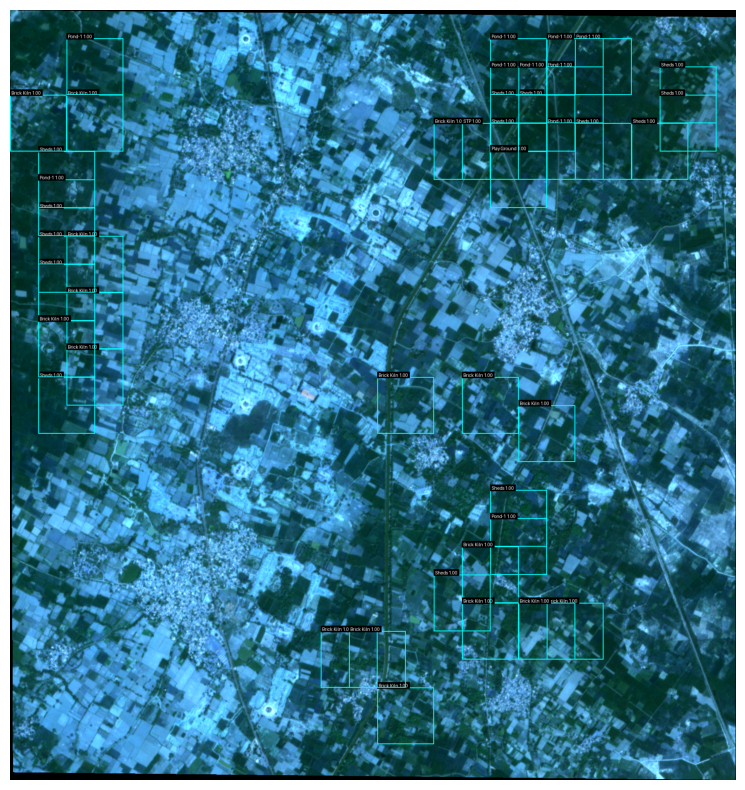

In [ ]:
# Show one overlay inline by filename
import matplotlib.pyplot as plt

SAMPLE_SHOW = os.path.basename(saved[0]) if saved else None
print("Example overlay:", SAMPLE_SHOW)

if SAMPLE_SHOW:
    plt.figure(figsize=(10,10))
    plt.imshow(Image.open(saved[0]))
    plt.axis('off')
    plt.show()


#Generating Hash File

In [ ]:

!zip -r "GC_PS03_31-Oct-2025_AIGR-S66845_Solution.zip" "/content/drive/MyDrive/Team PRAG Final Solution"

  adding: content/drive/MyDrive/Team PRAG Final Solution/ (stored 0%)
  adding: content/drive/MyDrive/Team PRAG Final Solution/PS03_visualseach_solution.ipynb (deflated 29%)
  adding: content/drive/MyDrive/Team PRAG Final Solution/Copy of encoder_moco_resnet50_4ch_ep360.pt (deflated 8%)
  adding: content/drive/MyDrive/Team PRAG Final Solution/requirements.txt (deflated 42%)
  adding: content/drive/MyDrive/Team PRAG Final Solution/utills / (stored 0%)
  adding: content/drive/MyDrive/Team PRAG Final Solution/utills /Copy of preprocess.json (deflated 50%)
  adding: content/drive/MyDrive/Team PRAG Final Solution/README.md (deflated 52%)


In [ ]:
import hashlib

zip_path = "/content/drive/MyDrive/NCIIPC Startup Challenge/GC_PS03_31-Oct-2025_AIGR-S66845_Solution.zip"

def md5_of_file(filepath):
    hash_md5 = hashlib.md5()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

hash_value = md5_of_file(zip_path)
print("✅ MD5 Hash Value:", hash_value)


✅ MD5 Hash Value: 123c25fb2ebbb6474915a7ccb75e9ae8


In [ ]:
hash_file_path = "/content/drive/MyDrive/NCIIPC Startup Challenge/GC_PS03_31-Oct-2025_AIGR-S66845_Hash.txt"

with open(hash_file_path, "w") as f:
    f.write(hash_value + "\n")

print("✅ Saved hash file at:", hash_file_path)


✅ Saved hash file at: /content/drive/MyDrive/NCIIPC Startup Challenge/GC_PS03_31-Oct-2025_AIGR-S66845_Hash.txt
